# Team Challenge SQL
## Parte 1: SQL Murder

### Enunciado

<div align="center">
<blockquote>
<p><em>A crime has taken place and the detective needs your help.</em></p>
<p><em>The detective gave you the crime scene report, but you somehow lost it.</em></p>
<p><em>You vaguely remember that the crime was a <strong>murder</strong> that occurred sometime on <strong>Jan.15, 2018</strong> and that it took place in <strong>SQL City</strong>.</em></p>
<p><em>Start by retrieving the corresponding crime scene report from the police department's database.</em></p>
</blockquote>
</div>


### Modelo de datos
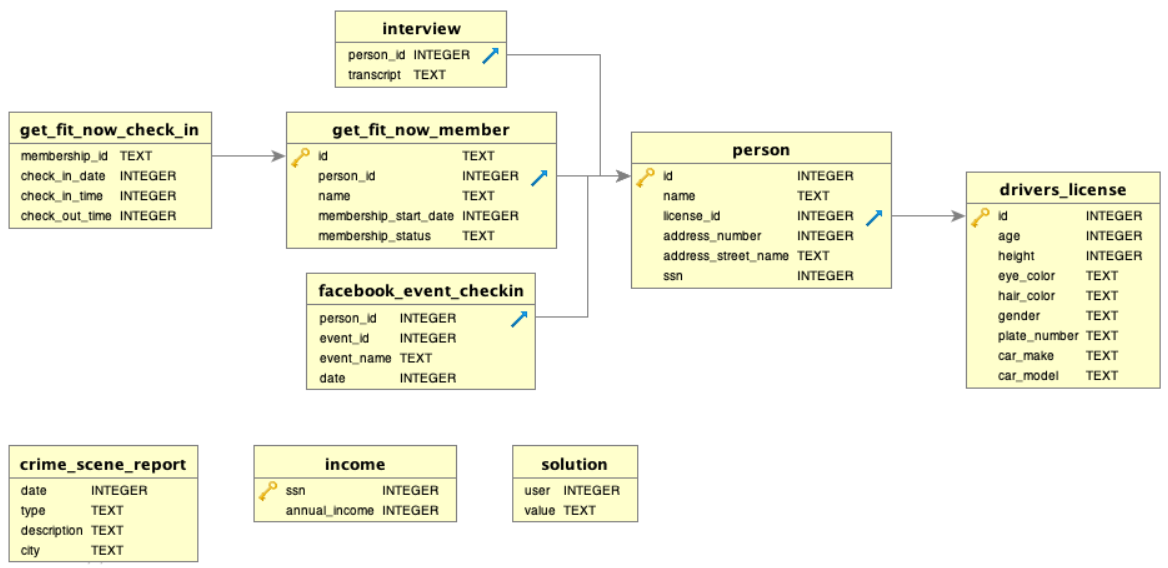

### Empezamos la investigación: accedemos al *crime_scene_report*

Comenzamos leyendo la información inicial que tenemos del caso. Ejecutamos el siguiente request

In [ ]:
select *
from crime_scene_report
where date = "20180115" and type = "murder" and city = "SQL City"

Resultado:

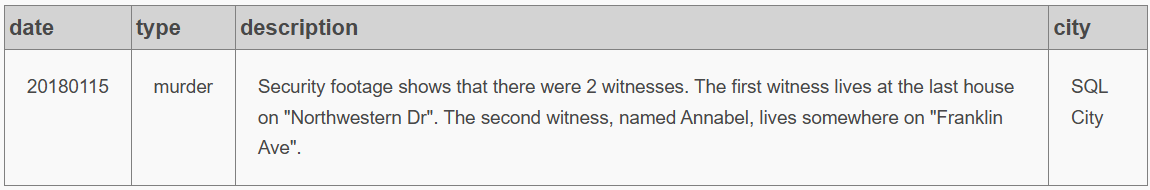


### Tenemos dos testigos, comprobamos la identidad de cada uno por separado en *person*

Empezamos con el primero, accediendo a la dirección mencionada y ordenando los datos de forma descendente para que nos salga la última casa de aquella dirección.

In [ ]:
select *
from person
where address_street_name = "Northwestern Dr"
order by address_number DESC

Resultado:

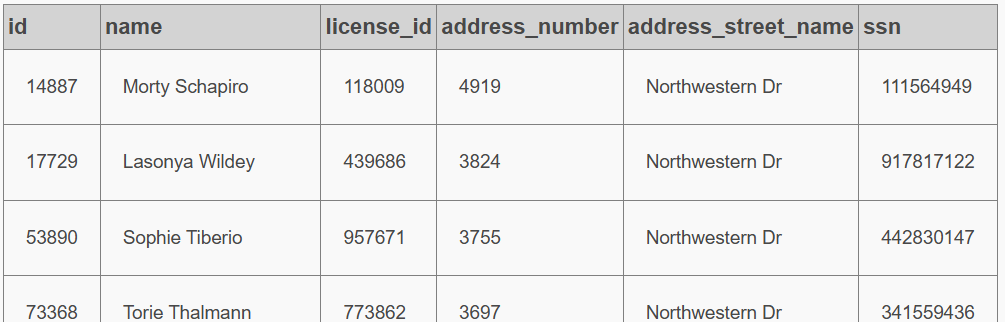

Ya sabemos que nuestro primer testigo es **Morty Schapiro**

Seguimos con el segundo testigo. Sabemos, de momento, que se llama Annabel y que vive en Franklin Ave. Veamos:

In [ ]:
select *
from person
where address_street_name = "Franklin Ave" and name LIKE "%Annabel%"

Resultado:

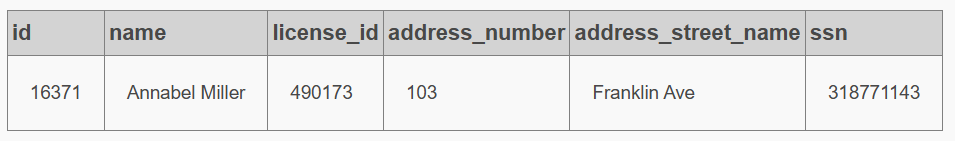

Hemos accedido a todos sus datos.

### Con la información que hemos conseguido pasamos a ver sus declaraciones en *interview*

Introducimos su documento identificativo

In [ ]:
select *
from interview
where person_id IN ("14887", "16371")

Resultado:

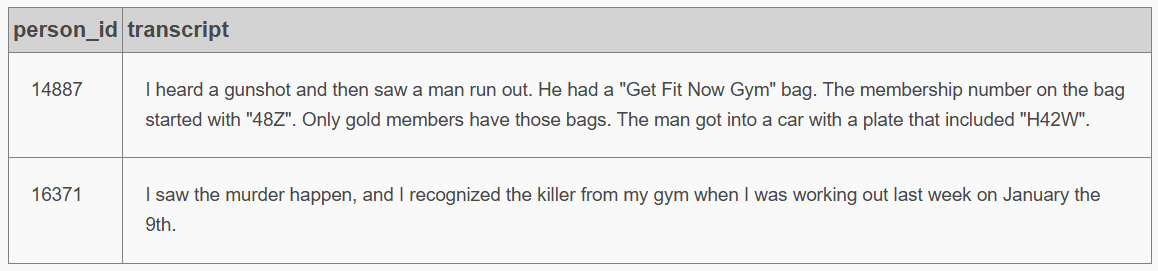

Información relevante: datos sobre la matricula del coche, numero y tipo de miembresia en el gimnasio, avistamiento del asesino en el gimnasio el 09.01.2018.
Investigamos en ese orden en su correspondiente BBDD.

### Obtenemos los ID de licencia de conducir de las personas que coinciden con la matricula en *drivers_license*

In [ ]:
select id
from drivers_license
where plate_number like"%H42W%"

Resultado:

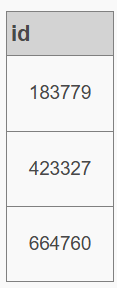

### Cruzamos los datos entre *person* y *drivers_license* para obtener el ID de esas personas

Indicamos que son iguales ciertas columnas entre BBDD para que se pueda hacer correctamente el request

In [ ]:
select A.id as licencia, b.id as id_persona, b.name
from drivers_license as A
left join person as b
on A.id = b.license_id
where a.id in ("183779","423327","664760")

Resultado:

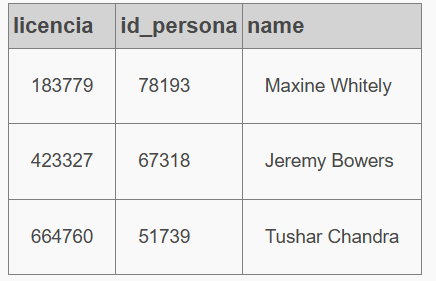

Estos son los posibles sospechosos

### Cruzamos *get_fit_now_member* y *person* para obtener el ID del gimnasio del sospechoso 

Indicamos que es igual ciertas columnas entre BBDD para que se pueda hacer correctamente el request

Además, especificamos el tipo de membresía, para que sea lo más concreto posible

In [ ]:
select A.id as id_gym, b.id as id_persona
from get_fit_now_member as A
left join person as b
on A.person_id = b.id
where b.id in ("78193","67318","51739") and membership_status = "gold"

Resultado:

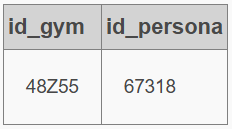

Lo tenemos! 

### Comprobemos que estuvo en el gimnasio el 09.01.2018. en *get_fit_now_check_in*

In [ ]:
select *
from get_fit_now_check_in
where membership_id = "48Z55"

Resultado:

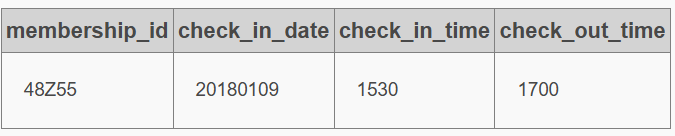

Afirmativo

### Obtenemos el nombre del asesino volviendo a *person*

In [ ]:
select *
from person
where id = "67318"

Resultado:

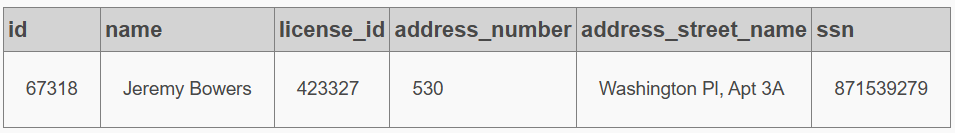

Jeremy es el asesino.

### Comprobamos la solución

In [ ]:
INSERT INTO solution VALUES (1, 'Jeremy Bowers');
        
        SELECT value FROM solution;

Resultado:

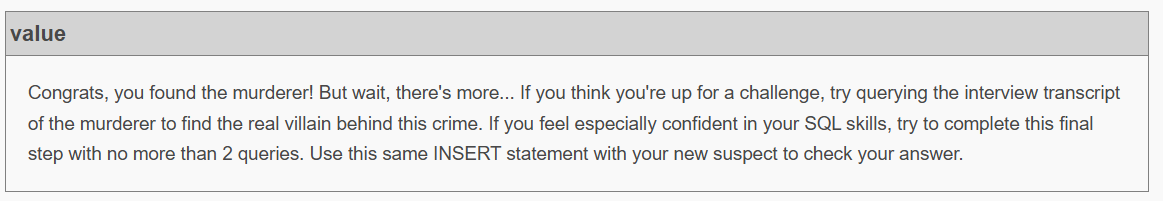



### Investigamos quien podría estar detrás en *interview* de Jeremy

In [ ]:
select *
from interview
where person_id = "67318"

Resultado:

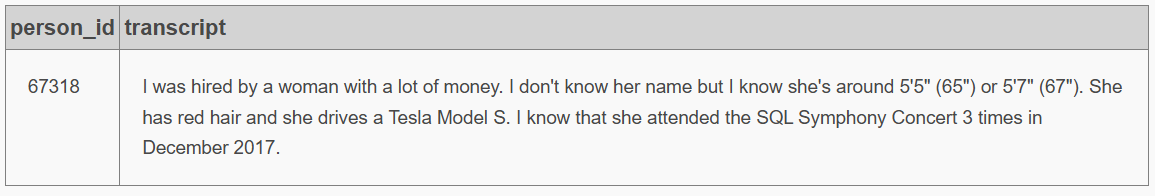

### Introducimos los datos obtenidos en *drivers_license*

In [ ]:
select A.id as id_licencia, B.name as nombre, B.id as id_persona
from drivers_license as A
left join person as B
on a.id = B.license_id
where gender = "female" and (height >= 65 or height <= 67) and hair_color = "red" and car_make = "Tesla" and car_model = "Model S"

Resultado:

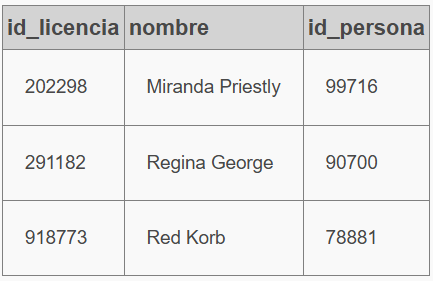

Tenemos a tres sospechosas. Investiguemos más.

### Consultamos quién es la mujer con esas características en *facebook_event_checkin*

In [ ]:
SELECT 
    B.id AS id_persona,
    B.name AS nombre
FROM facebook_event_checkin AS A
JOIN person AS B
    ON A.person_id = B.id
JOIN drivers_license AS C         
ON B.license_id = C.id
WHERE 
    A.event_name = 'SQL Symphony Concert'
    AND A.date LIKE '201712%'
    AND C.hair_color = 'red'
    AND C.car_make = 'Tesla'
    AND C.car_model = 'Model S'
GROUP BY 
    B.id, B.name
HAVING 
    COUNT(A.event_id) = 3

Resultado:

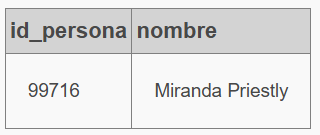

La tenemos.

### Comprobamos por última vez

In [ ]:
INSERT INTO solution VALUES (1, 'Miranda Priestly');
        
        SELECT value FROM solution;

Resultado:

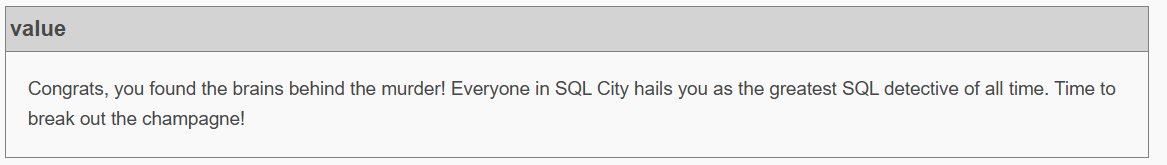